In [1]:
import keras
import tensorflow as tf
from IPython.display import Image
import matplotlib.pyplot as plt
from keras import layers
from keras import ops


In [2]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=(96, 96),   # downscaling
    color_mode="grayscale",
    batch_size=32
)

Found 2128 files belonging to 3 classes.


In [3]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=(96, 96),   # downscaling
    color_mode="grayscale",
    batch_size=32
)


Found 766 files belonging to 3 classes.


2


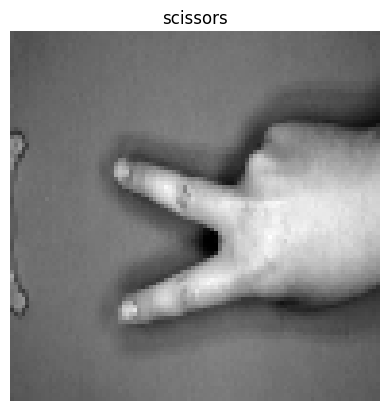

In [4]:

class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):

    image = images[0].numpy()
    label = labels[0].numpy()
    
    print(label)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [18]:
model = keras.Sequential(
    [
   layers.Conv2D(24, (3, 3), activation="relu", input_shape=(96, 96, 1)),
   layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3,activation='softmax')

    ]
)

c:\Users\loren\anaconda3\envs\MLstat\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 94, 94, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 47, 47, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 53016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     3,393,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393,523 (12.95 MB)

 Trainable params: 3,393,523 (12.95 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.fit(train_dataset, validation_data=validation_dataset, epochs=10)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3783 - loss: 189.9087 - val_accuracy: 0.9125 - val_loss: 0.3650
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8435 - loss: 0.7362 - val_accuracy: 0.9843 - val_loss: 0.0932
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9492 - loss: 0.1515 - val_accuracy: 0.9817 - val_loss: 0.1064
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9776 - loss: 0.0773 - val_accuracy: 0.9869 - val_loss: 0.0718
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9913 - loss: 0.0285 - val_accuracy: 0.9883 - val_loss: 0.0525
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9892 - loss: 0.0310 - val_accuracy: 0.9896 - val_loss: 0.0655
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9981 - loss: 0.0110 - val_accuracy: 0.9935 - val_loss: 0.0590
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9994 - loss: 0.0041 - val_accuracy: 0.9935 -

In [21]:
for images, labels in validation_dataset.take(1):
    
    image = images[0]
    label = labels[0]
    prediction = model.predict(image[None, ...])

    print(f"Predicted label: {prediction.argmax()}")
    print(f"Actual label: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted label: 1
Actual label: 1


In [ ]:
model.predict(validation_dataset)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


array([[0.33333334, 0.33333334, 0.33333334],
       [0.33333334, 0.33333334, 0.33333334],
       [0.33333334, 0.33333334, 0.33333334],
       ...,
       [0.33333334, 0.33333334, 0.33333334],
       [0.33333334, 0.33333334, 0.33333334],
       [0.33333334, 0.33333334, 0.33333334]], dtype=float32)